In [1]:
from src import *
from src.extra import ExEstimates

from src.parallelize import parallelize # 简单的多进程并行实现, 依赖于 dask

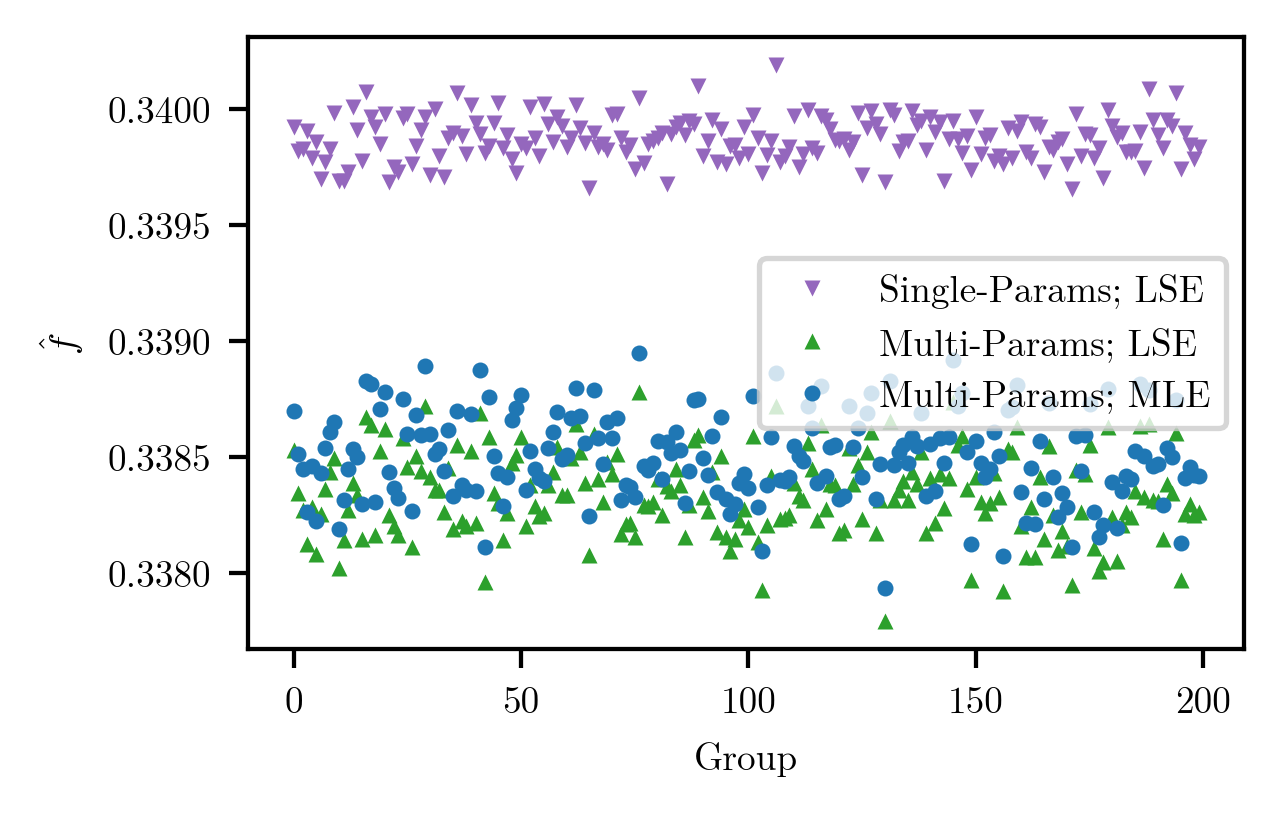

In [ ]:
# 创建 MetaData 对象, 包含元数据
# DMD.A(x) = x * DMD.PIXEL_SIZE / 2, 用于快速计算振幅
# 这个 MetaData 表示做的模拟是 DI, 频率是 0.34, 振幅是 5/2 个 DMD Pixels.
meta = MetaData('DI', 0.34, DMD.A(5))  

# 创建模拟器对象, 并生成模拟数据
# gen() 方法会返回一个标准的 Estimates 实例
# gen() 接受不同的信号和噪声光子数, 缺省则为 DI 400, SPADE 60.
c = Simulator(meta, 'sign').gen()  

# 对生成的数据进行估计 (非拓展 Estimates 用的是单参数 LSE, 和原先一样)
c = c.est()  
x = np.arange(200)  
plt.plot(x, c.estimates, 'v', label='Single-Params; LSE')  

# 使用 ExEstimates 进行拓展估计
c = ExEstimates(c)  

# 进行 LSE 估计 (多参数)
c = c.lse()  
plt.plot(x, c.extra_estimates_f, '^', label='Multi-Params; LSE')  

# 进行 MLE 估计 (多参数, Kay1993, 有近似所以和多参数 LSE 相比有细微区别)
c = c.mle()  
plt.plot(x, c.extra_estimates_f, 'o', label='Multi-Params; MLE')  

plt.xlabel('Group')  
plt.ylabel(r'$\hat f$')
plt.legend()  
plt.show()  


In [3]:
# MLE 估计的振幅和理论相符
c.extra_estimates_a.mean(), (4/pi) * DMD.A(5)

(62.34970773842478, 61.67166765676177)

In [4]:
# 实验的 f 是从 0.1 -> 0.4 的
freq_list = np.linspace(0.1, 0.4, 61)


# 这个元组内的两个参数会通过 np.random.normal(*delay_params) 来产生随机数.
# 也就是元组内第一个参数表示延迟的均值, 第二个参数表示延迟的标准差.
# 这个延迟量是试出来的. 其中 1e-6 是实验中人为添加的, 用于等待 DMD 等其他仪器.
delay_params = (2.8e-3 + 1e-6, 0.48e-3)

In [5]:
@parallelize() # 这个装饰器会将原函数的第一个参数转换为接受计算图输入. 由于模拟用的算法没有经过矢量化优化, 效率不高, 因此使用多进程并行加速
def run(f, m):
    meta = MetaData(m, np.round(f, 5), DMD.A(3))
    c = Simulator(meta, 'sign', delay_params).gen()
    c = c.est() # est() 方法是目前文中展示的数据所采用的处理方法, 即 MLE 估计 Time-Domain, 单参数 LSE 估计 Frequency.
    c.savez('TEMP/') # TEMP 文件夹不随 git 同步, savez() 只需要给出存储路径, 程序会自动命名.
    return c

cs1, cs2 = run(freq_list, 'DI'), run(freq_list, 'SPADE')

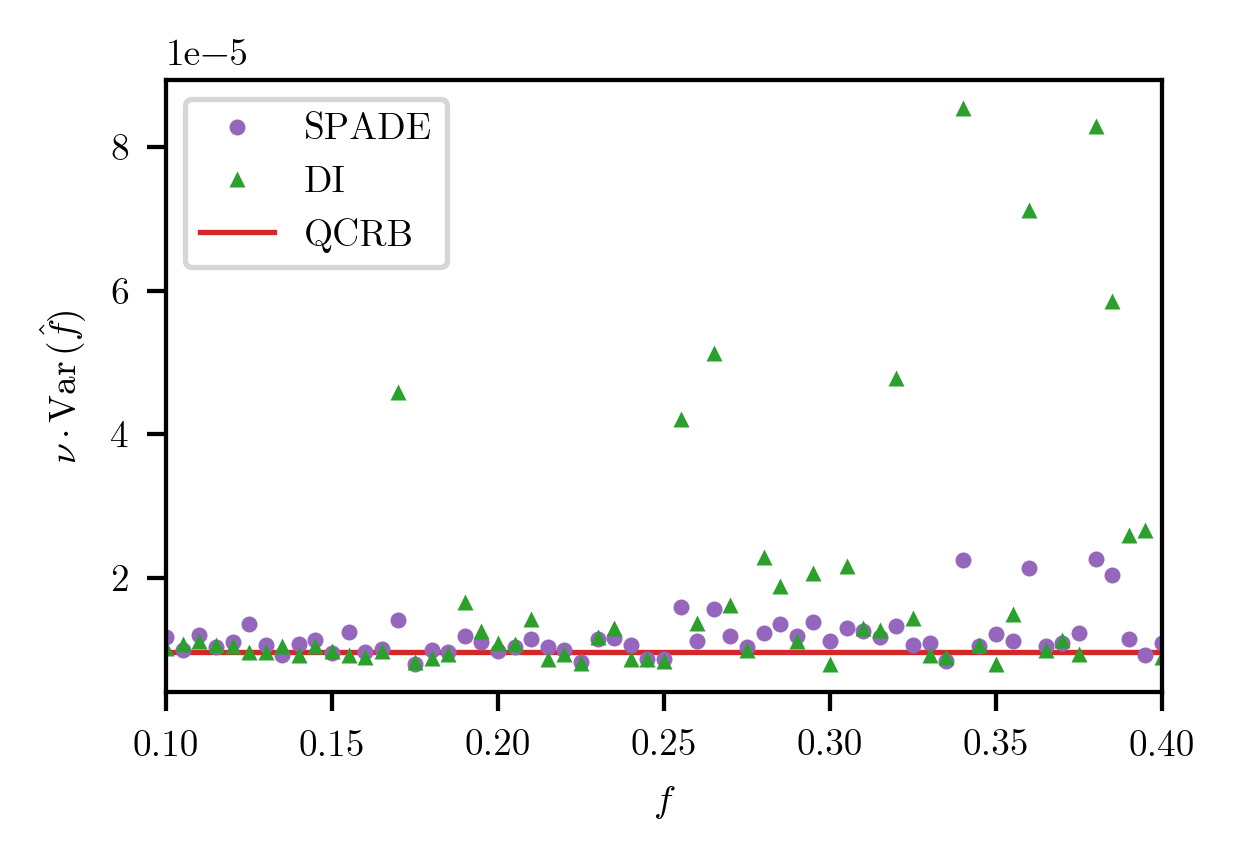

In [ ]:
for m in ('SPADE', 'DI'):
    f_var = []
    for i, f in enumerate(freq_list):
        meta = MetaData(m, np.round(f, 5), DMD.A(3)) # MetaData 的方法 convert2str() 能方便得到文件名
        c = LoadEstimates(f'TEMP/{meta.convert2str()}.npz') # LoadEstimates() 能读取一个被保存的 Estimates 类
        f_var.append(c.estimates.var(ddof=1) * c.photons)
    plt.plot(freq_list, f_var, 'o' if m == 'SPADE' else '^', label=m)

# FI 的计算在 SPADE 和 DI 类之下. 由于无噪声的情况下, SPADE 和 DI 的 CFI 相等, 所以可以任选其一进行计算
fi = DI.ApproxCFI((4/pi) * DMD.A(3))
plt.axhline(1/fi, color='tab:red', zorder=1, label='QCRB') # QCRB = CRB

plt.legend()
plt.xlim(0.1, 0.4)
plt.xlabel(r'$f$')
plt.ylabel(r'$\nu\cdot{\rm Var\,}(\hat f)$')
plt.show()